# Auditoría de licencias: ¿qué se anuncia sin licencia válida?

Responde a **[M-08]** de `docs/prd.md`: qué parte de la oferta anunciada no acredita licencia.

La diferencia con `02_exploracion_airbnb.ipynb` es el paso decisivo: allí se audita si el anuncio **declara** algo en el campo `license`; aquí se comprueba si lo que declara **existe en el registro oficial**.

> Este notebook **no reimplementa** la clasificación: lee la salida de `pipeline/transform/auditar_licencias.py`, para que el criterio viva en un solo sitio.

```bash
python pipeline/transform/auditar_licencias.py
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path('../..')
pd.set_option('display.max_columns', None)

d = pd.read_csv(RAIZ / 'data/processed/airbnb_situacion_licencia.csv')
sujetos = d[d['sujeto_a_vut']]
candidatos = d[d['candidato_sin_licencia']]
caso_aparte = d[d['candidato_host_con_licencia']]

print(f'Anuncios               : {len(d):,}')
print(f'Sujetos al régimen VUT : {len(sujetos):,}')
print(f'Candidatos             : {len(candidatos):,}  ({candidatos["host_id"].nunique()} anfitriones)')
print(f'Caso aparte            : {len(caso_aparte):,}  ({caso_aparte["host_id"].nunique()} anfitriones)')

Anuncios               : 15,406
Sujetos al régimen VUT : 8,996
Candidatos             : 399  (258 anfitriones)
Caso aparte            : 274  (109 anfitriones)


## 1. Los tres filtros que acotan el universo

### a) Solo la oferta sujeta al régimen VUT

La normativa catalana define estancia turística como *"període de temps continu igual o inferior a 31 dies"*. La clave es que **mide cada cesión por separado, no el acumulado del año**: alquilar 31 días doce veces son doce estancias turísticas y exige licencia; un solo inquilino 40 días seguidos, no.

El único dato que acredita la exención es `minimum_nights >= 32`: si la plataforma no deja reservar menos, ninguna estancia puede ser turística. Una habitación privada va por otro régimen (*llar compartida*).

In [2]:
universo = pd.DataFrame({'anuncios': [
    len(d),
    (d['room_type'] != 'Entire home/apt').sum(),
    ((d['room_type'] == 'Entire home/apt') & (d['minimum_nights'] >= 32)).sum(),
    len(sujetos),
]}, index=['Total en Airbnb', '— habitaciones (llar compartida)',
           '— vivienda completa, mínimo 32+ noches (temporada)', '= Sujetos al régimen VUT'])
universo

,anuncios
Total en Airbnb,15406
— habitaciones (llar compartida),4562
"— vivienda completa, mínimo 32+ noches (temporada)",1847
= Sujetos al régimen VUT,8996


### b) Solo la oferta con clientes

Un anuncio sin reservas recientes no describe oferta en circulación: la licencia que le falte no dice nada sobre el mercado. Se exige reseña dentro del año del snapshot, así que **2025 y anteriores quedan fuera** aunque el anuncio siga publicado.

### c) El anfitrión que acredita licencia en otro anuncio suyo va aparte

Quien ya ha declarado una licencia válida en otro piso conoce el trámite. Que falte en este apunta más a un descuido al rellenar el campo que a operar al margen del registro, así que se cuenta en su propia categoría.

In [3]:
sin_acreditar = sujetos[sujetos['situacion'].isin(['sin_declarar', 'licencia_no_encontrada'])]
embudo = pd.DataFrame({'anuncios': [
    len(sujetos), len(sin_acreditar),
    (~sin_acreditar['actividad_reciente']).sum(),
    len(caso_aparte), len(candidatos),
]}, index=['Sujetos al régimen VUT', '— sin licencia acreditada',
           '   — descartados por falta de actividad en 2026',
           '   — anfitrión acredita en otro anuncio (caso aparte)',
           '= CANDIDATOS'])
embudo

,anuncios
Sujetos al régimen VUT,8996
— sin licencia acreditada,1698
— descartados por falta de actividad en 2026,1025
— anfitrión acredita en otro anuncio (caso aparte),274
= CANDIDATOS,399


## 2. Situación de los anuncios sujetos a licencia VUT

In [4]:
resumen = sujetos['situacion'].value_counts().to_frame('anuncios')
resumen['%'] = (resumen['anuncios'] / len(sujetos) * 100).round(1)
resumen

,anuncios,%
situacion,,
licencia_verificada,6006,66.8
sin_declarar,1177,13.1
exencion_declarada,1029,11.4
licencia_no_encontrada,521,5.8
hutb_no_verificable,189,2.1
licencia_otro_regimen,74,0.8


Cuatro trampas del campo `license`, todas encontradas sobre los datos reales:

**1. Contiene dos números distintos.** El nacional (NRUA, obligatorio desde julio de 2025 por el RD 1312/2024) incrusta la licencia autonómica y le añade dígitos: `ESFCTU...HUTB-002062349` frente al real `HUTB-002062`. Buscar `HUTB-\d+` en todo el campo captura el equivocado y elevaba las licencias "no encontradas" del 14,8% al 36,2%.

**2. La sección regional no solo lleva HUTB.** También hoteles (`HB-`), albergues (`AJ`) y apartamentos turísticos (`ATB-`): están acreditados, solo que bajo otro régimen.

**3. A veces el HUTB solo aparece en el número nacional.** Declaran licencia, pero no se puede leer cuál — el nacional coincide con el regional solo el 95,2% de las veces, y los desajustes son números distintos, no truncamientos.

**4. Un número puede ser imposible.** Por encima del último emitido por la Generalitat no puede corresponder a ninguna licencia real.

In [5]:
print('Regímenes declarados en la sección regional:')
print(d['prefijo_licencia'].fillna('(nada legible)').value_counts().to_string())
print(f"\nLicencias declaradas fuera del rango emitido: {int(d['fuera_de_rango'].sum()):,}")
print('Ejemplos:', sorted(d.loc[d['fuera_de_rango'], 'hutb'].dropna().unique())[-6:])

Regímenes declarados en la sección regional:
prefijo_licencia
HUTB                  7228
(nada legible)        7084
HB                     670
AJ                     203
HUTB_SOLO_NACIONAL     193
ATB                     28

Licencias declaradas fuera del rango emitido: 889
Ejemplos: ['HUTB-987000', 'HUTB-987654', 'HUTB-987890', 'HUTB-988770', 'HUTB-990666', 'HUTB-995187']


## 3. Los dos grupos, en categorías excluyentes

Conviene no mezclarlos: en el **grupo A** el anfitrión ya acredita licencia en otros pisos suyos; en el **grupo B** no la acredita en ninguno.

In [6]:
def desglosar(sub, nombre):
    filas = {
        'No declara nada': sub['situacion'] == 'sin_declarar',
        'Número imposible (fuera de rango)': sub['fuera_de_rango'] == True,  # noqa: E712
        'Número plausible pero inexistente': (sub['situacion'] == 'licencia_no_encontrada')
                                             & (sub['fuera_de_rango'] != True),  # noqa: E712
    }
    return pd.DataFrame(
        [{'grupo': nombre, 'categoría': k, 'anuncios': int(m.sum()),
          'anfitriones': sub.loc[m, 'host_id'].nunique()} for k, m in filas.items()])


pd.concat([
    desglosar(caso_aparte, 'A · el anfitrión acredita en otro anuncio'),
    desglosar(candidatos, 'B · no acredita en ninguno'),
]).set_index(['grupo', 'categoría'])

anuncios  \
grupo                                     categoría                                     
A · el anfitrión acredita en otro anuncio No declara nada                          40   
                                          Número imposible (fuera de rango)       165   
                                          Número plausible pero inexistente        69   
B · no acredita en ninguno                No declara nada                         220   
                                          Número imposible (fuera de rango)       146   
                                          Número plausible pero inexistente        33   

                                                                             anfitriones  
grupo                                     categoría                                       
A · el anfitrión acredita en otro anuncio No declara nada                             27  
                                          Número imposible (fuera de rango)           56  
                                          Número plausible pero inexistente           45  
B · no acredita en ninguno                No declara nada                            126  
                                          Número imposible (fuera de rango)          109  
                                          Número plausible pero inexistente           24

Los anfitriones no suman entre categorías: uno puede tener anuncios en varias.

## 4. ¿Están activos? Actividad del grupo B en 2026

In [7]:
c = candidatos.copy()
c['ult'] = pd.to_datetime(c['last_review'], errors='coerce')
por_mes = c['ult'].dt.to_period('M').value_counts().sort_index()
desde_marzo = c[c['ult'] >= '2026-03-01']

print('Última reseña, por mes (snapshot 24/06/2026):')
print(por_mes.to_string())
print(f'\nCon reseña desde marzo de 2026: {len(desde_marzo):,} '
      f'({len(desde_marzo) / len(c):.1%}, en {desde_marzo["host_id"].nunique()} anfitriones)')

Última reseña, por mes (snapshot 24/06/2026):
ult
2026-01     25
2026-02     19
2026-03     27
2026-04     43
2026-05     70
2026-06    214
2026-07      1
Freq: M

Con reseña desde marzo de 2026: 355 (89.0%, en 240 anfitriones)


## 5. ¿Cuánto duran las estancias? El hueco entre reseñas

El snapshot no trae la duración de las estancias, pero el fichero de reseñas sí trae la fecha de cada una. **El hueco entre reseñas consecutivas de un mismo anuncio es un techo de la estancia intermedia**: incluye la estancia más los días vacíos hasta el siguiente huésped, y si alguien no reseña, dos estancias se cuentan como una.

El sesgo **infla** los huecos. Por tanto el porcentaje de estancias cortas que salga de aquí es un **suelo**, no un techo.

In [8]:
reseñas = pd.read_csv(
    RAIZ / 'data/raw/airbnb/insideairbnb_barcelona_2026-06-24_reviews.csv', parse_dates=['date'])


def huecos(ids, desde='2024-07-01'):
    r = reseñas[reseñas['listing_id'].isin(set(ids))].sort_values(['listing_id', 'date'])
    r = r.assign(hueco=r.groupby('listing_id')['date'].diff().dt.days)
    r = r[(r['date'] >= desde) & (r['hueco'] > 0)]
    return r


h = huecos(desde_marzo['id'])
tramos = pd.cut(h['hueco'], [0, 3, 7, 14, 31, 60, 120, 10**5],
                labels=['1-3', '4-7', '8-14', '15-31', '32-60', '61-120', '120+'])
tabla = tramos.value_counts().sort_index().to_frame('huecos')
tabla['%'] = (tabla['huecos'] / len(h) * 100).round(1)
print(f'{len(h):,} huecos medidos en {h["listing_id"].nunique()} anuncios (últimos 24 meses)')
print(f'Huecos de 31 días o menos: {(h["hueco"] <= 31).mean():.1%}\n')
tabla

11,078 huecos medidos en 307 anuncios (últimos 24 meses)
Huecos de 31 días o menos: 92.6%



,huecos,%
hueco,,
1-3,3514,31.7
4-7,3789,34.2
8-14,2049,18.5
15-31,910,8.2
32-60,397,3.6
61-120,201,1.8
120+,218,2.0


### El caso del alojamiento "para estudiantes"

Dos operadores del grupo se presentan como residencia de estudiantes y declaran no ser para turistas. El régimen legal, sin embargo, no depende de a quién se alquile sino de **cuánto dura cada cesión**.

In [9]:
for host in ['BLAU Student Housing', 'La Fabrica &Co']:
    g = d[d['host_name'] == host]
    h = huecos(g['id'], desde='2025-01-01')
    print(f'{host}: {len(g)} anuncios, mínimo de noches {sorted(g["minimum_nights"].unique())}')
    if len(h):
        print(f'  {len(h):,} huecos medidos | mediana {h["hueco"].median():.0f} días '
              f'| ≤31 días: {(h["hueco"] <= 31).mean():.1%}')
    print()

BLAU Student Housing: 5 anuncios, mínimo de noches [np.float64(3.0)]
  668 huecos medidos | mediana 1 días | ≤31 días: 98.4%

La Fabrica &Co: 10 anuncios, mínimo de noches [np.float64(2.0), np.float64(3.0), np.float64(31.0)]
  351 huecos medidos | mediana 2 días | ≤31 días: 90.6%



Un hueco mediano de uno o dos días implica reseñas casi diarias en el mismo estudio: rotación de estancias cortas, no alojamiento de curso académico — un estudiante que se queda un cuatrimestre deja una reseña cada varios meses.

Lo que el dato **no** dice: si esos huéspedes son estudiantes. Solo cuánto duran las cesiones, que es lo que determina el régimen.

## 6. Concentración por distrito y anfitrión

In [10]:
por_distrito = pd.DataFrame({
    'sujetos': sujetos.groupby('neighbourhood_group').size(),
    'candidatos': candidatos.groupby('neighbourhood_group').size(),
}).fillna(0).astype(int)
por_distrito['% candidatos'] = (por_distrito['candidatos'] / por_distrito['sujetos'] * 100).round(1)
por_distrito.sort_values('% candidatos', ascending=False)

,sujetos,candidatos,% candidatos
neighbourhood_group,,,
Ciutat Vella,1370,125,9.1
Sant Martí,885,62,7.0
Sant Andreu,88,6,6.8
Les Corts,192,12,6.2
Sants-Montjuïc,946,44,4.7
Gràcia,859,28,3.3
Horta-Guinardó,193,6,3.1
Sarrià-Sant Gervasi,511,14,2.7
Eixample,3869,100,2.6


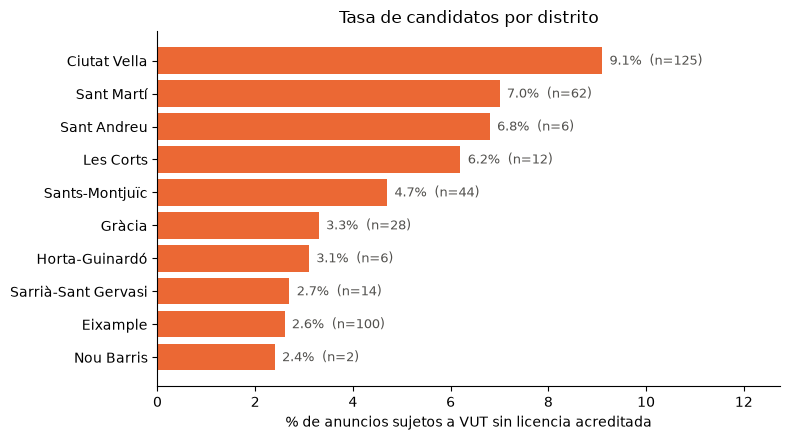

In [11]:
orden = por_distrito.sort_values('% candidatos')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(orden.index, orden['% candidatos'], color='#eb6834')
for i, (pct, n) in enumerate(zip(orden['% candidatos'], orden['candidatos'])):
    ax.text(pct + 0.15, i, f'{pct}%  (n={n})', va='center', fontsize=9, color='#52514e')
ax.set_xlabel('% de anuncios sujetos a VUT sin licencia acreditada')
ax.set_title('Tasa de candidatos por distrito')
ax.set_xlim(0, orden['% candidatos'].max() * 1.4)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

In [12]:
por_host = candidatos.groupby(['host_id', 'host_name']).size().sort_values(ascending=False)
print(f'Anfitriones con algún candidato: {len(por_host):,}')
print(f'  con 1 anuncio: {(por_host == 1).sum():,}   con 5 o más: {(por_host >= 5).sum():,} '
      f'({por_host[por_host >= 5].sum():,} anuncios)')
por_host.head(10).to_frame('anuncios candidatos')

Anfitriones con algún candidato: 258
  con 1 anuncio: 208   con 5 o más: 10 (96 anuncios)


,,anuncios candidatos
host_id,host_name,
346367515.0,Ukio,31
64805231.0,Marc,11
250042982.0,Miki,9
146682595.0,Ana & Rafa,8
2262273.0,Rosa,7
574822979.0,La Fabrica &Co,7
542371304.0,Hotel Tembo Barcelona,6
4258623.0,08028,6
397090058.0,Caterina,6


## Conclusiones

**Lo que se puede afirmar**

- El cruce con el registro funciona: dos tercios de los anuncios sujetos a licencia la acreditan verificablemente.
- Hay licencias declaradas **numéricamente imposibles**, por encima del último número emitido.
- Los candidatos que quedan tras filtrar por actividad **operan de verdad**: todos con reseñas en 2026, y los huecos entre reseñas muestran estancias mayoritariamente por debajo de 31 días.
- Los anuncios etiquetados como alojamiento estudiantil muestran rotación diaria, incompatible con estancias de curso.

**Lo que NO se puede afirmar**

- Que un candidato sea ilegal. El campo lo rellena el anfitrión sin validación: una licencia real mal escrita cae en el mismo grupo.
- La duración exacta de ninguna estancia: el hueco entre reseñas es un techo, no una medida.
- Nada sobre una vivienda concreta: las coordenadas de Inside Airbnb están desplazadas ~200 m.
- Que cubra el mercado: solo Airbnb.

**Siguiente paso [M-08]:** el mapa de clusters con la columna `situacion` y la agregación por barrio en `export.py`.